# Tutorial - Mean Squared Displacement (MSD)

Here we show how to compute the MSD on a trajectory with snow. For physical interpretation, check out our paper presenting snow.

-----------

First, we will load some data from the molecular dynamics simulation of a sintering event (three copper nanoparticles simultaneously colliding).

In [44]:
from snow.io.xyz import read_xyz_movie

el, frames = read_xyz_movie('sintering.xyz')
nframes = len(frames)
natoms  = len(frames[0])

print(f'Loaded trajectory of {nframes} frames with {natoms} atoms')

Loaded trajectory of 401 frames with 165 atoms


Now we use snow to compute the MSD:

In [45]:
from snow.descriptors.time_dependent import compute_MSD

msd = compute_MSD(frames)

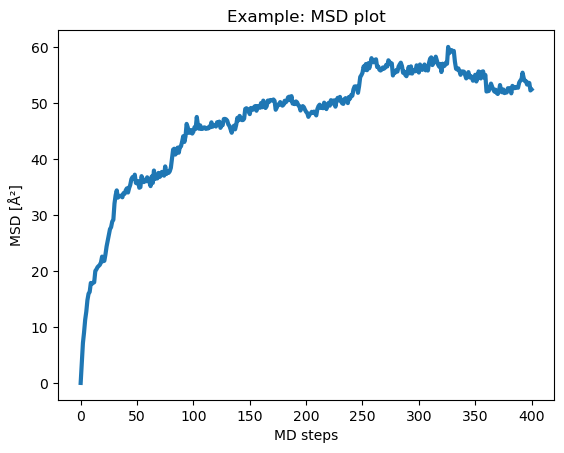

In [53]:
#optional plot
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(msd))

plt.figure()
plt.plot(steps, msd, lw=3.0)
plt.xlabel('MD steps')
plt.ylabel('MSD [Å²]')
plt.title('Example: MSD plot')
plt.show()

It is also possible to compute the MSD per-group to look at the contribution to the general MSD from a restricted number of atoms: for example, in this sintering simulation, we might wnat to check out the contribution of each seed (the initial nanoparticles) to the total MSD. This is done via masks that select atoms from their IDs (make sure the ordering of the atoms in the movie is consistent!).

In [47]:
#per-group MSD

n_atoms_single_np = 55
mask_1 = [True]*n_atoms_single_np + [False]*(natoms-n_atoms_single_np)
mask_2 = [False]*n_atoms_single_np + [True]*n_atoms_single_np + [False]*n_atoms_single_np
mask_3 = [False]*(natoms-n_atoms_single_np) + [True]*n_atoms_single_np

#apply the same mask throughout the entire simulation
mask_1 = [mask_1]*nframes
mask_2 = [mask_2]*nframes
mask_3 = [mask_3]*nframes

msd_1 = compute_MSD(frames, masks=mask_1)
msd_2 = compute_MSD(frames, masks=mask_2)
msd_3 = compute_MSD(frames, masks=mask_3)

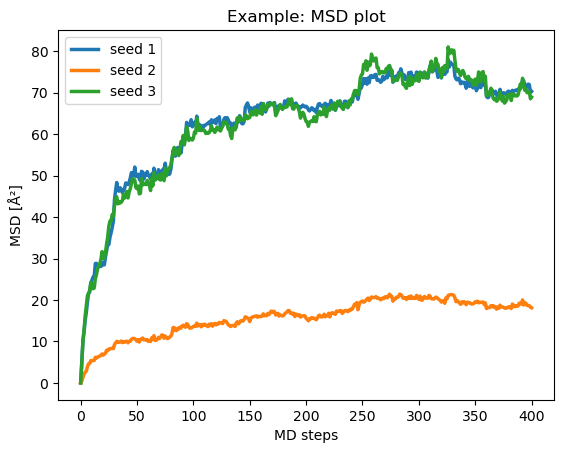

In [55]:
#optional plot
steps = np.arange(len(msd))

plt.figure()
plt.plot(steps, msd_1, label='seed 1', lw=2.5)
plt.plot(steps, msd_2, label='seed 2', lw=2.5)
plt.plot(steps, msd_3, label='seed 3', lw=2.5)
plt.xlabel('MD steps')
plt.ylabel('MSD [Å²]')
plt.title('Example: MSD plot')
plt.legend()
plt.show()

From the plot you can see that different initial seeds contribute with different extents to the total MSD, with two seeds in particular (the two external ones) contributing the most to the displacement in the system.